# 🧠 Algoritmo de Bernstein-Vazirani

Desenvolvido por Ethan Bernstein e Umesh Vazirani em 1992, este algoritmo é considerado uma extensão natural do Algoritmo de Deutsch-Jozsa. Ele é famoso por demonstrar como um computador quântico pode extrair uma sequência inteira de informações escondidas em uma única operação, algo que é matematicamente impossível para computadores clássicos.

## 🎯 O Problema de Bernstein-Vazirani

Imagine que temos uma função "caixa preta" (oráculo) $f$ que recebe uma string de $n$ bits (vamos chamá-la de $x$) e retorna um único bit (0 ou 1). 

A promessa do problema é que essa função esconde uma **string secreta $s$** (também de $n$ bits). O resultado da função é sempre o produto interno bit a bit (módulo 2) entre a sua entrada $x$ e a string secreta $s$. Matematicamente:

$$f(x) = x \cdot s = (x_0s_0 \oplus x_1s_1 \oplus \dots \oplus x_{n-1}s_{n-1}) \pmod 2$$

O objetivo é simples: **Descobrir qual é a string secreta $s$.**

## 🚀 A Vantagem Quântica

*   **Abordagem Clássica:** A maneira mais eficiente de um computador clássico descobrir $s$ é testando cada bit individualmente. Ele precisa enviar as entradas $100...0$, depois $010...0$, e assim por diante. Se a string secreta tiver $n$ bits, o algoritmo clássico precisará de exatamente **$n$ consultas** à função.
*   **Abordagem Quântica:** O Algoritmo de Bernstein-Vazirani consegue extrair toda a string secreta $s$ de uma só vez, fazendo **apenas 1 única consulta** à função, independentemente de a string ter 5 bits ou 1 milhão de bits.

## ⚙️ Como Funciona (Resumo do Circuito)

1.  **Preparação:** O circuito utiliza $n$ qubits de dados inicializados em $|0\rangle$ e $1$ qubit auxiliar (*ancilla*) inicializado em $|1\rangle$.
2.  **Superposição:** Portas Hadamard são aplicadas a todos os $n+1$ qubits. Os qubits de dados entram em superposição uniforme, e o qubit auxiliar muda para o estado negativo $|-\rangle$.
3.  **Oráculo (Phase Kickback):** A função quântica $U_f$ é aplicada. Como o qubit auxiliar está no estado $|-\rangle$, o resultado da função não é gravado como 0 ou 1, mas sim transferido para as fases (sinais) da superposição dos qubits de dados (fenômeno do *Phase Kickback*). O estado quântico agora "carrega" a informação de $s$ em suas fases.
4.  **Interferência:** Portas Hadamard são aplicadas novamente apenas aos $n$ qubits de dados. Essa etapa reverte a superposição, mas as fases alteradas no passo anterior causam uma interferência perfeita que aponta exatamente para o estado clássico da string $s$.
5.  **Medição:** Medimos os $n$ qubits de dados. O colapso da função de onda resultará, com **100% de probabilidade**, nos exatos bits que compõem a string secreta $s$.

In [ ]:
#BIBLIOTECAS
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# CHAVE SECRETA E TAMANHO DELA
secret_s = "110101010"
n = len(secret_s)

In [ ]:
# DEFINIR CIRCUITO
dev = qml.device("default.qubit", wires = n+1, shots=1)


In [ ]:
#ORACULO
def oracle (wires, s):
    for i, bit in enumerate(s): # ENUMERACAO DOS BITS
        if bit == '1': # COLOCA UMA CNOT EM TODOS OS BITS IGUAIS A 1
            qml.CNOT(wires=[i,n])

In [80]:
@qml.qnode(dev) # definir circuito
def bernstein_vazirani_circuit():
    qml.PauliX(wires = n) #Criar Bit auxiliar
    qml.Hadamard(wires=n) #Criar Bit auxiliar 
    for i in range(n):
        qml.Hadamard(wires=i)# Hadarmard em todos os bits principais

    oracle(range(n+1),secret_s)#Oraculo normal
    for i in range(n):
        qml.Hadamard(wires=i) #hadamard pra fechar tudo
    return qml.sample(wires=range(n))

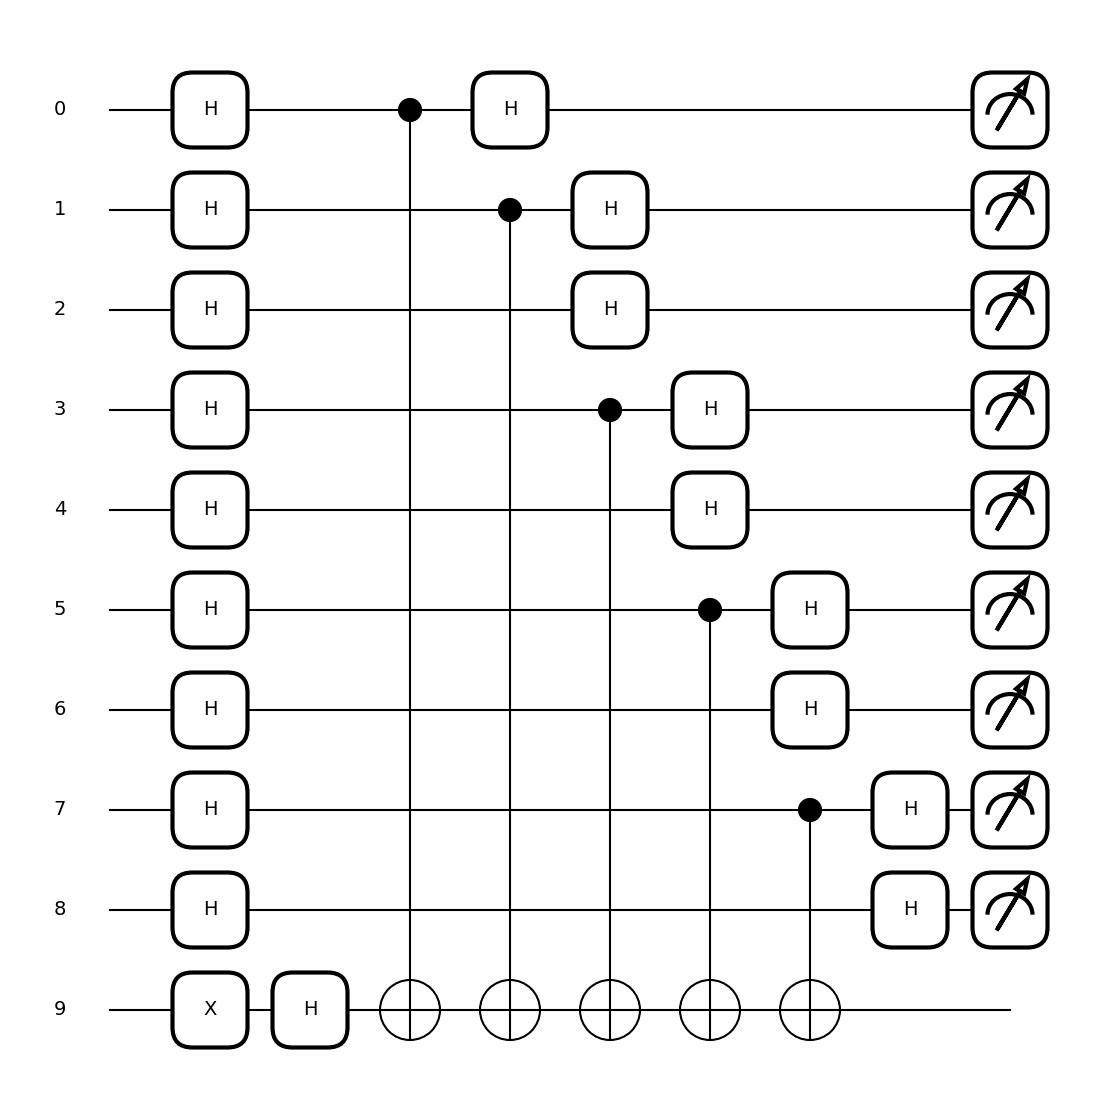

In [83]:
fig,ax =qml.draw_mpl(bernstein_vazirani_circuit)()#desenho pra ver se ta certo

In [84]:
result = bernstein_vazirani_circuit()
print(f"String secreta definida:{secret_s}")
print(f"Resultado da medicao unica: {''.join(map(str,result))}")

String secreta definida:110101010
Resultado da medicao unica: 110101010


In [ ]:
#BIBLIOTECAS
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# CHAVE SECRETA E TAMANHO DELA
secret_s = "110101010"
n = len(secret_s)

In [ ]:
# DEFINIR CIRCUITO
dev = qml.device("default.qubit", wires = n+1, shots=1)


In [ ]:
#ORACULO
def oracle (wires, s):
    for i, bit in enumerate(s): # ENUMERACAO DOS BITS
        if bit == '1': # COLOCA UMA CNOT EM TODOS OS BITS IGUAIS A 1
            qml.CNOT(wires=[i,n])

In [ ]:
@qml.qnode(dev) # definir circuito
def bernstein_vazirani_circuit():
    qml.PauliX(wires = n) #Criar Bit auxiliar
    qml.Hadamard(wires=n) #Criar Bit auxiliar 
    for i in range(n):
        qml.Hadamard(wires=i)# Hadarmard em todos os bits principais

    oracle(range(n+1),secret_s)#Oraculo normal
    for i in range(n):
        qml.Hadamard(wires=i) #hadamard pra fechar tudo
    return qml.sample(wires=range(n))

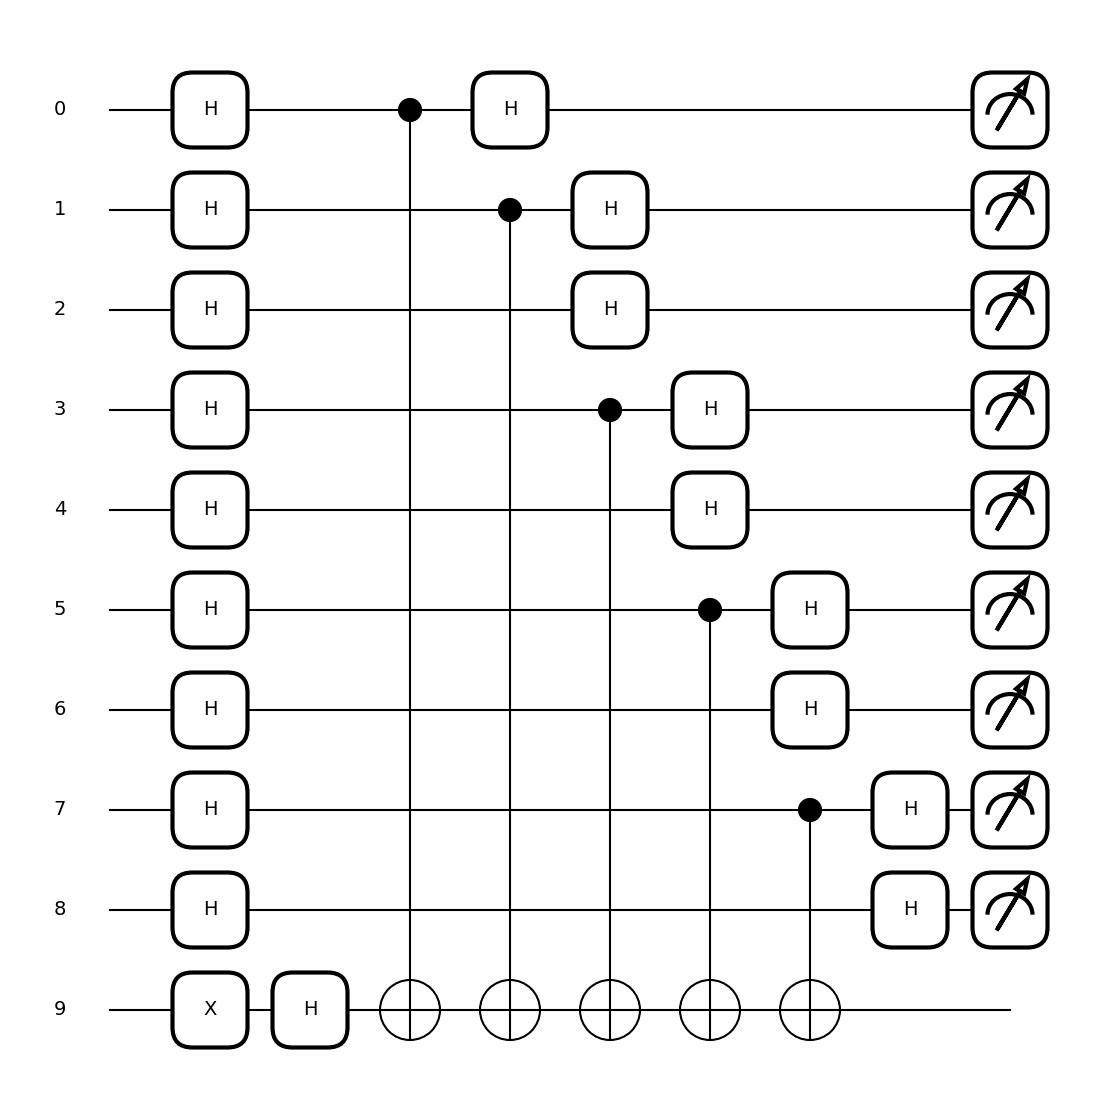

In [ ]:
fig,ax =qml.draw_mpl(bernstein_vazirani_circuit)()#desenho pra ver se ta certo

In [ ]:
result = bernstein_vazirani_circuit()
print(f"String secreta definida:{secret_s}")
print(f"Resultado da medicao unica: {''.join(map(str,result))}")

String secreta definida:110101010
Resultado da medicao unica: 110101010
